<a href="https://colab.research.google.com/github/kanny789/ddo-data-dev/blob/main/Credit_Card_Anomaly_Detection-revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql.functions import col, count, sum, window, expr, floor
from pyspark.sql.functions import explode_outer
from pyspark.sql.functions import col, log1p
from pyspark.sql.window import Window
from pyspark.sql.functions import log1p
from pyspark.sql.functions import sum as _sum, count


In [2]:
%pip install kagglehub[pandas-datasets] # DBTITLE 1,Load the dataset

In [3]:
# Load the latest version
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_351/3638448700.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
First 5 records:    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ...

In [4]:
import pandas as pd
import numpy as np

# Drop duplicates
df = df.drop_duplicates()

# Cast columns
df["Time"] = df["Time"].astype(float)
df["Amount"] = df["Amount"].astype(float)
df["Class"] = df["Class"].astype(int)

for i in range(1, 29):
    df[f"V{i}"] = df[f"V{i}"].astype(float)

silver_clean = df.copy()


In [5]:
silver_clean["HourOfDay"] = np.floor(silver_clean["Time"] / 3600) % 24
silver_clean["HourOfDay"] = silver_clean["HourOfDay"].astype(int)

silver_clean["IsNight"] = ((silver_clean["HourOfDay"] < 6) |
                           (silver_clean["HourOfDay"] > 22)).astype(int)

silver_time = silver_clean.copy()

In [6]:
silver_clean["Amount_log"] = np.log1p(silver_clean["Amount"])
silver_amount =silver_clean.copy()
print(silver_amount)


            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V24       V25  \
0       0.462388  0.239599  0.098698  0.363787  ...  0.06692

In [7]:


# Ensure data is sorted by Time (Spark Window.orderBy)
silver_amount = silver_amount.sort_values("Time").reset_index(drop=True)

# Previous Time
silver_amount["PrevTime"] = silver_amount["Time"].shift(1)

# Time since previous
silver_amount["TimeSincePrev"] = silver_amount["Time"] - silver_amount["PrevTime"]

# Previous Amount
silver_amount["PrevAmount"] = silver_amount["Amount"].shift(1)

# Amount difference
silver_amount["AmountDiff"] = (silver_amount["Amount"] - silver_amount["PrevAmount"]).round(2)

# Amount ratio (safe divide)
silver_amount["AmountRatio"] = (silver_amount["Amount"] / silver_amount["PrevAmount"]).replace([np.inf, -np.inf], np.nan).round(2)

print(silver_amount)





            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
283721  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
283722  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
283723  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
283724  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
283725  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...  Amount  Class  HourOfDay  \
0       0.462388  0.239599  0.098698  0.363787  ...  1

In [8]:
# Define feature columns
feature_cols = [f"V{i}" for i in range(1, 29)] + [
    "Amount_log", "HourOfDay", "IsNight",
    "TimeSincePrev", "AmountDiff", "AmountRatio"
]

# Select only the relevant columns (Class + features)
df_sel = silver_amount[["Class"] + feature_cols]

# Drop rows with NaN in any of the feature columns
df_sel = df_sel.dropna(subset=feature_cols)

# Count rows
print("Rows:", len(df_sel))

Rows: 281917


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Impute missing numeric values with median

y = df_sel["Class"].astype(int)
X = df_sel.drop(columns=["Class"])


# Standardize features
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# --- Impute using TRAIN ONLY ---
median_vals = X_train_full.median()

X_train_full = X_train_full.fillna(median_vals)
X_val = X_val.fillna(median_vals)
X_test = X_test.fillna(median_vals)

# --- Train only on normal samples ---
X_train = X_train_full[y_train_full == 0]

# --- Scale using TRAIN ONLY ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [10]:


import builtins
from tensorflow.keras import layers, models

input_dim = X_train.shape[1]
encoding_dim = builtins.max(8, input_dim // 3)

inp = layers.Input(shape=(input_dim,))
x = layers.Dense(encoding_dim*2, activation="relu")(inp)
x = layers.Dense(encoding_dim, activation="relu")(x)
x = layers.Dense(encoding_dim*2, activation="relu")(x)
out = layers.Dense(input_dim, activation="linear")(x)
latent = layers.Dense(encoding_dim, activation="relu", name="latent_layer")(x)

autoencoder = models.Model(inputs=inp, outputs=out)
autoencoder.compile(optimizer="adam", loss="mse")
encoder = models.Model(inputs=inp, outputs=latent)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 22)             │           770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           253 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 22)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 34)             │           782 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,069 (8.08 KB)

 Trainable params: 2,069 (8.08 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
import tensorflow as tf
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, X_val),
    shuffle=True
)

Epoch 1/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.7409 - val_loss: 0.5941
Epoch 2/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5369 - val_loss: 0.5001
Epoch 3/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4693 - val_loss: 0.4578
Epoch 4/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4356 - val_loss: 0.4366
Epoch 5/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4165 - val_loss: 0.4244
Epoch 6/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4030 - val_loss: 0.4081
Epoch 7/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3921 - val_loss: 0.3987
Epoch 8/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3832 - val_loss: 0.3914
Epoch 9/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3756 - val_loss: 0.3856
Epoch 10/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3700 - val_loss: 0.3823
Epoch 11/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3664 - val_loss: 0.3791
Epoch 12/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [12]:
import numpy as np

# 1. Get reconstructions for the validation set
recon = autoencoder.predict(X_val)

# 2. Compute reconstruction error
errors = np.mean(np.square(X_val - recon), axis=1)

# 3. Choose threshold (example: 99.5th percentile of validation errors)
threshold = np.percentile(errors, 99.5)

# 4. Flag anomalies
anomaly_flags = errors > threshold

# 5. Evaluate using validation labels
from sklearn.metrics import precision_recall_curve, auc, precision_score, recall_score, f1_score

precision, recall, _ = precision_recall_curve(y_val, errors)
auprc = auc(recall, precision)

preds = (errors > threshold).astype(int)

print("AUPRC:", auprc)
print("Threshold:", threshold)
print("Precision:", precision_score(y_val, preds))
print("Recall:", recall_score(y_val, preds))
print("F1:", f1_score(y_val, preds))

1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step
AUPRC: 0.4172965090306617
Threshold: 2.9162490247707242
Precision: 0.2358490566037736
Recall: 0.704225352112676
F1: 0.35335689045936397


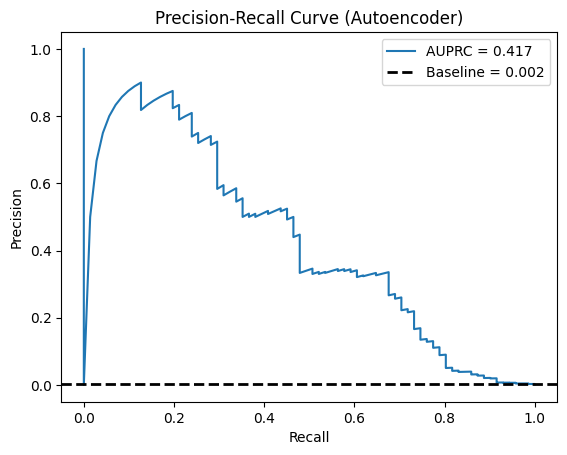

In [13]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
# Baseline line
baseline = y_val.mean()
plt.axhline(y=baseline, color='black', linestyle='--', linewidth=2,
            label=f"Baseline = {baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Autoencoder)")
plt.legend()

plt.show()


In [14]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, errors)

# Example: maximize F1
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)

Best threshold: 7.548329085472553


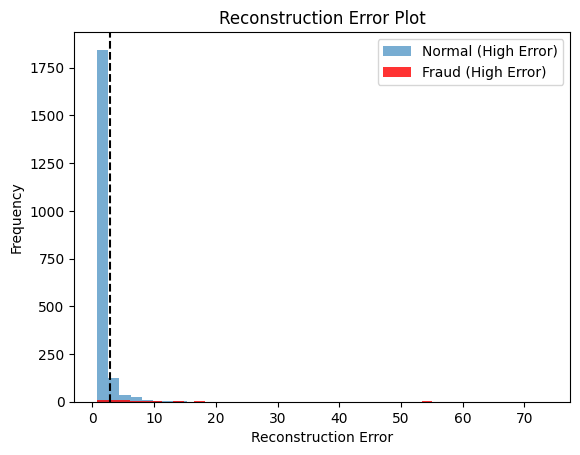

In [15]:
import matplotlib.pyplot as plt
import numpy as np
cut = np.percentile(errors, 95)
mask = errors > cut

plt.hist(errors[mask & (y_val==0)], bins=40, alpha=0.6, label="Normal (High Error)")
plt.hist(errors[mask & (y_val==1)], bins=40, alpha=0.8, label="Fraud (High Error)", color="red")
plt.axvline(threshold, color='black', linestyle='--')
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Plot")
plt.legend()
plt.show()

In [16]:
!pip install mlflow
import mlflow
import mlflow.keras
import joblib
import os

# Set experiment (in Colab this just creates a local tracking dir unless you connect to a remote MLflow server)
mlflow.set_experiment("autoencoder_fraud")

with mlflow.start_run():

    # Log encoding dimension safely
    mlflow.log_param("encoding_dim", int(encoding_dim) if encoding_dim is not None else None)

    # Log model
    mlflow.keras.log_model(autoencoder, "autoencoder_model")

    from google.colab import drive
    drive.mount('/content/drive')
    # Save scaler locally in Colab
    scaler_path = "/content/drive/MyDrive/scaler.joblib"
    joblib.dump(scaler, scaler_path)

    # Log artifact from local path
    mlflow.log_artifact(scaler_path)

    # Safe AUPRC logging
    try:
        mlflow.log_metric("auprc", float(auprc))
    except:
        mlflow.log_metric("auprc", -1.0)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.3 MB/s eta 0:00:00


2026/03/22 12:32:53 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/22 12:32:53 INFO mlflow.store.db.utils: Updating database tables
2026/03/22 12:32:56 INFO mlflow.tracking.fluent: Experiment with name 'autoencoder_fraud' does not exist. Creating a new experiment.
2026/03/22 12:32:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 12:32:56 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Mounted at /content/drive


In [17]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Compute reconstruction errors on validation set
recon = autoencoder.predict(X_val)
errors = np.mean(np.square(X_val - recon), axis=1)

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_val, errors)

# Compute F1 scores (avoid division by zero)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

# Note: thresholds has length = len(f1_scores) - 1
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("Best threshold:", best_threshold)

1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step
Best threshold: 7.548329085472553


In [18]:
print(errors.min(), errors.max())

0.013885772612935872 73.79713218819622


In [19]:
Z = encoder.predict(X_val)

1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [20]:
!pip install umap-learn
import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, random_state=42)
Z_2d = reducer.fit_transform(Z)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


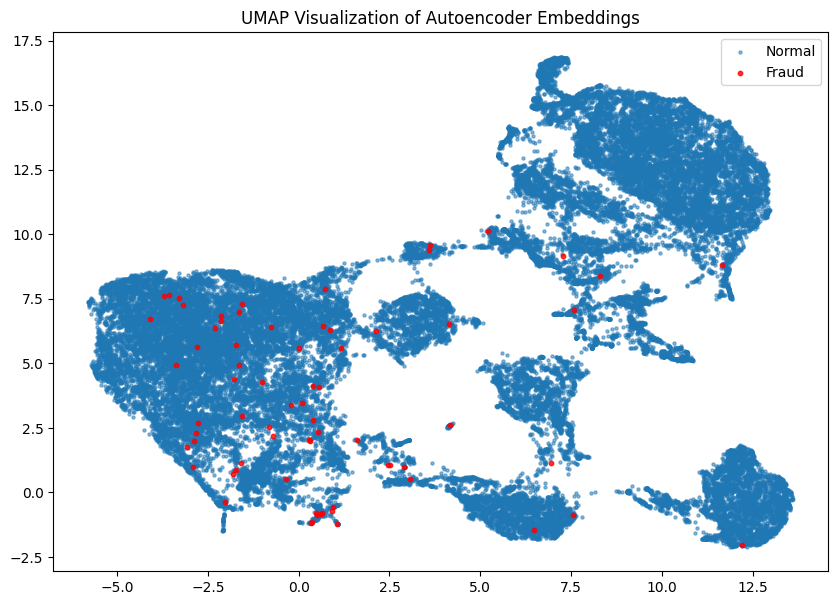

In [21]:
plt.figure(figsize=(10,7))
plt.scatter(Z_2d[y_val == 0, 0], Z_2d[y_val == 0, 1],
            s=5, alpha=0.5, label="Normal")
plt.scatter(Z_2d[y_val == 1, 0], Z_2d[y_val == 1, 1],
            s=10, alpha=0.8, label="Fraud", color="red")

plt.legend()
plt.title("UMAP Visualization of Autoencoder Embeddings")
plt.show()

1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1s 957us/step


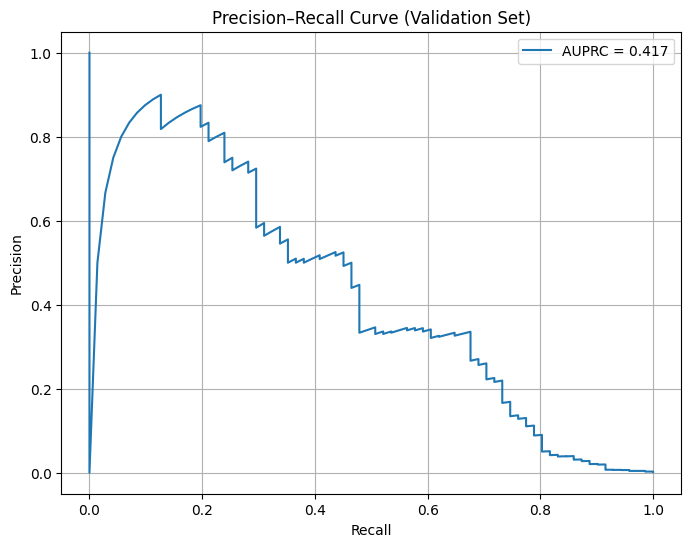

In [22]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. Compute reconstruction errors on validation set
recon = autoencoder.predict(X_val)
errors = np.mean(np.square(X_val - recon), axis=1)

# 2. Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_val, errors)

# 3. Compute AUPRC
auprc = auc(recall, precision)

# 4. Plot PR curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Validation Set)")
plt.legend()
plt.grid(True)
plt.show()

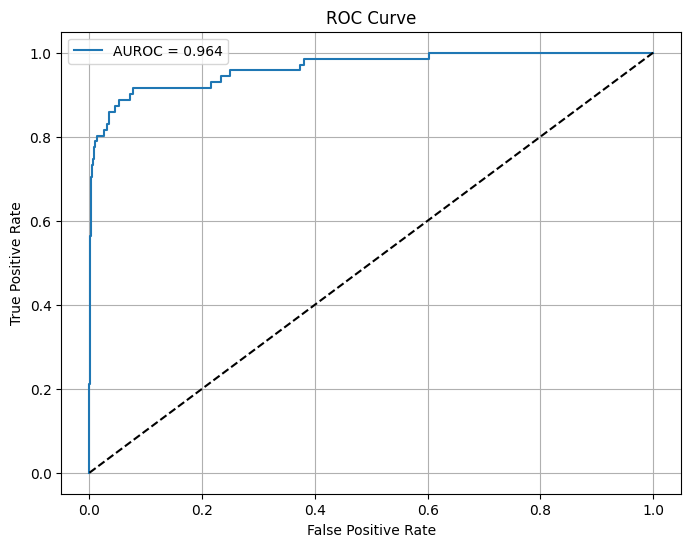

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_val, errors)
auroc = roc_auc_score(y_val, errors)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

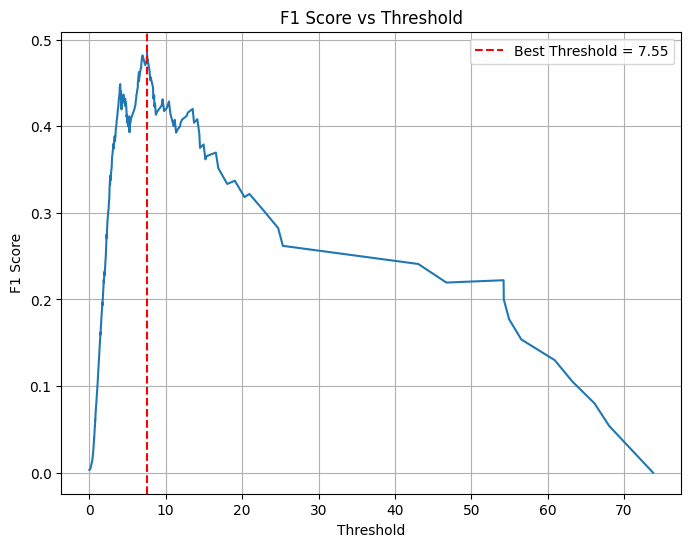

In [24]:
import numpy as np

f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

plt.figure(figsize=(8,6))
plt.plot(thresholds, f1_scores[:-1])
plt.axvline(best_threshold, color='red', linestyle='--', label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

#Testing

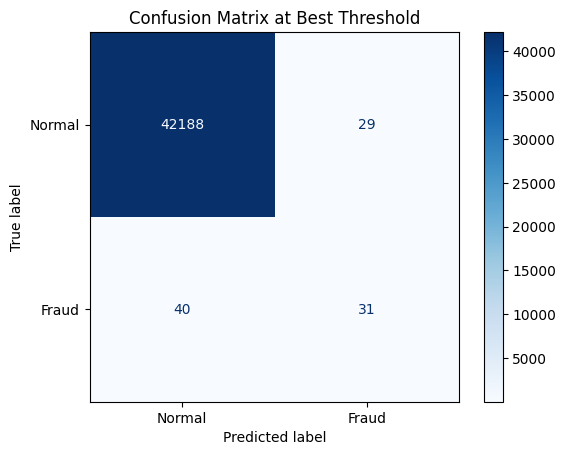

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds = (errors > best_threshold).astype(int)
cm = confusion_matrix(y_val, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix at Best Threshold")
plt.show()

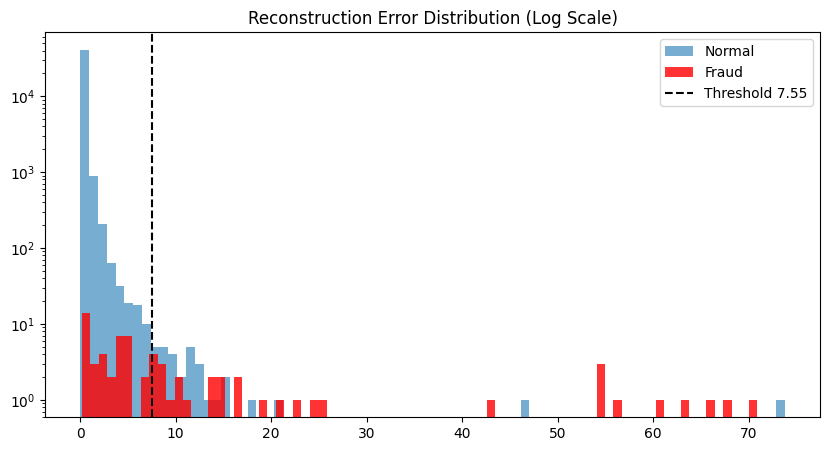

In [26]:
plt.figure(figsize=(10,5))
plt.hist(errors[y_val == 0], bins=80, alpha=0.6, label="Normal")
plt.hist(errors[y_val == 1], bins=80, alpha=0.8, label="Fraud", color="red")
plt.axvline(best_threshold, color='black', linestyle='--', label=f"Threshold {best_threshold:.2f}")
plt.yscale("log")
plt.legend()
plt.title("Reconstruction Error Distribution (Log Scale)")
plt.show()

In [27]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, roc_curve, confusion_matrix

# PR metrics
precision, recall, thresholds = precision_recall_curve(y_val, errors)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

# Predictions
preds = (errors > best_threshold).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()

# AUROC
auroc = roc_auc_score(y_val, errors)

# AUPRC
from sklearn.metrics import auc
auprc = auc(recall, precision)

print("AUPRC:", auprc)
print("AUROC:", auroc)
print("Best threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])
print("TP, FP, TN, FN:", tp, fp, tn, fn)
print("Error range:", errors.min(), errors.max())

AUPRC: 0.4172965090306617
AUROC: 0.9644422662654755
Best threshold: 7.548329085472553
Precision: 0.5245901639344263
Recall: 0.4507042253521127
F1: 0.48484848435135447
TP, FP, TN, FN: 31 29 42188 40
Error range: 0.013885772612935872 73.79713218819622


**# %Hybrid Scoring**

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


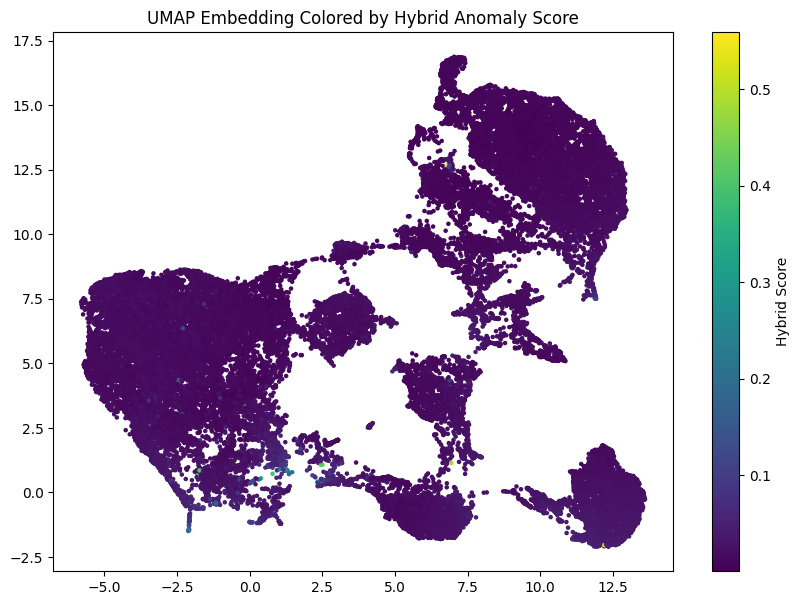

In [30]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# PR for reconstruction error
prec_e, rec_e, _ = precision_recall_curve(y_val, errors)
auprc_e = auc(rec_e, prec_e)

# PR for hybrid score
prec_h, rec_h, _ = precision_recall_curve(y_val, hybrid_score)
auprc_h = auc(rec_h, prec_h)

import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, random_state=42)
Z_2d = reducer.fit_transform(Z)

plt.figure(figsize=(10,7))
plt.scatter(Z_2d[:,0], Z_2d[:,1], c=hybrid_score, cmap="viridis", s=5)
plt.colorbar(label="Hybrid Score")
plt.title("UMAP Embedding Colored by Hybrid Anomaly Score")
plt.show()

In [28]:
Z_train = encoder.predict(X_train)
mu = Z_train.mean(axis=0)
latent_dist = np.linalg.norm(Z - mu, axis=1)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
E_norm = scaler.fit_transform(errors.reshape(-1,1)).flatten()
D_norm = scaler.fit_transform(latent_dist.reshape(-1,1)).flatten()
alpha = 0.5  # equal weighting
hybrid_score = alpha * E_norm + (1 - alpha) * D_norm






6157/6157 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


In [29]:
recon = autoencoder.predict(X_val)
errors = np.mean(np.square(X_val - recon), axis=1)

1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


**Dataset Description**

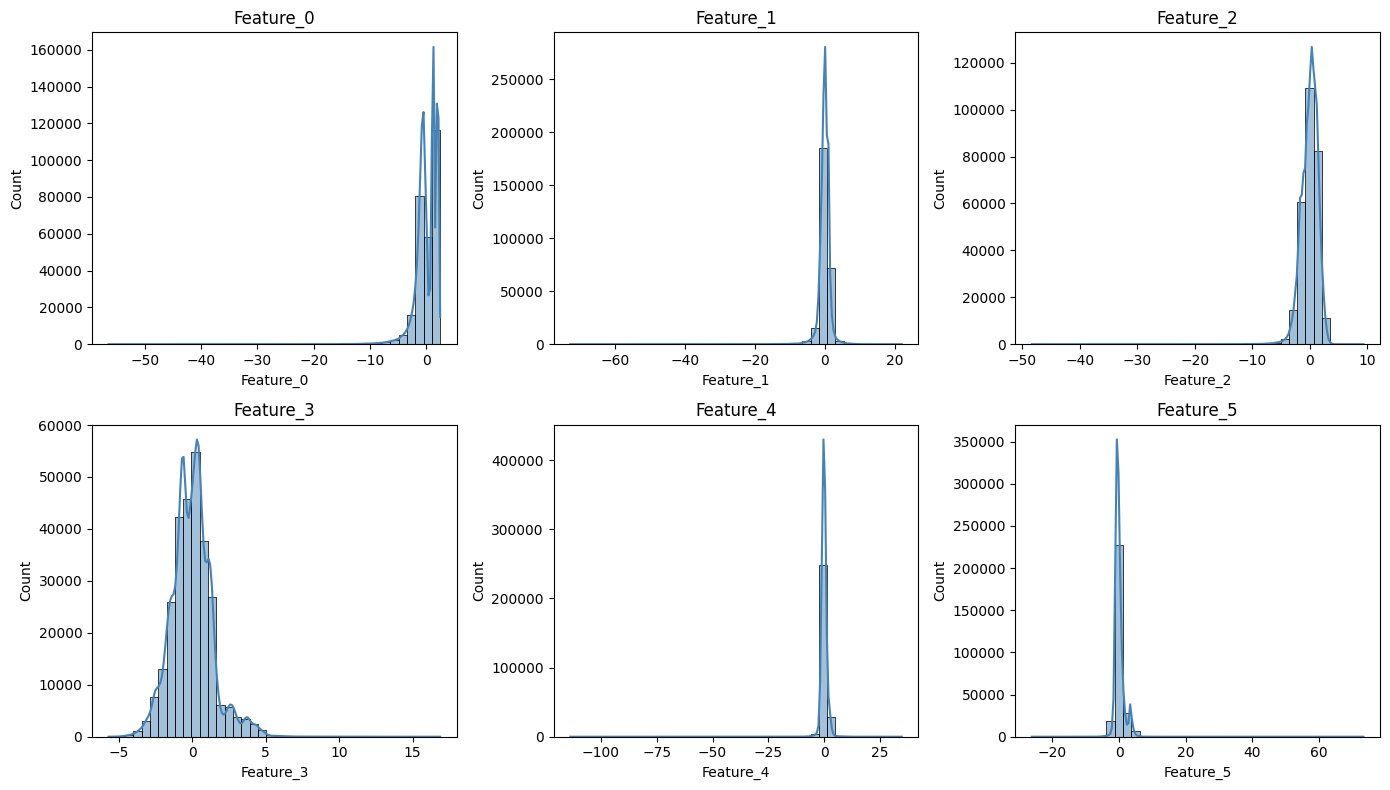

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

df = X.copy()
df.columns = [f"Feature_{i}" for i in range(df.shape[1])]

# Select first 6 features for snapshot
sample_features = df.iloc[:, :6]

plt.figure(figsize=(14,8))
for i, col in enumerate(sample_features.columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(sample_features[col], bins=40, kde=True, color="steelblue")
    plt.title(col)

plt.tight_layout()
plt.show()



/tmp/ipykernel_351/218299604.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


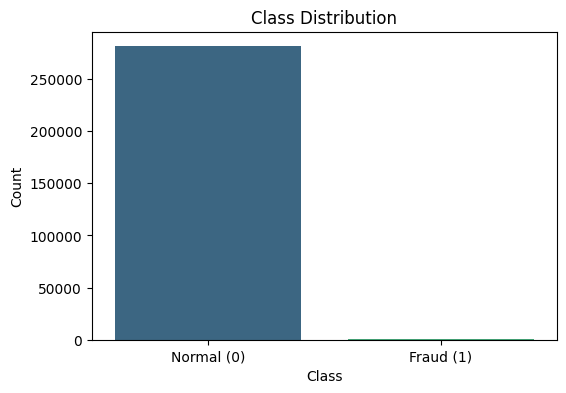

Class
0    281447
1       470
Name: count, dtype: int64


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming your labels are in y or y_val
class_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.xticks([0,1], ["Normal (0)", "Fraud (1)"])
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

print(class_counts)

In [49]:
print(type(silver_clean))
print(silver_clean.head())

<class 'pandas.core.frame.DataFrame'>
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V24       V25       V26       V27       V28  \
0  0.098698  0.363787  ...  0.066928  0.128539 -0.189115  0.133558 -0.021053   
1  0.085102 -0.255425  ... -0.339846  0.167170  0.125895 -0.008983  0.014724   
2  0.247676 -1.514654  ... -0.689281 -0.327642 -0.139097 -0.055353 -0.059752   
3  0.377436 -1.387024  ... -1.175575  0.647376 -0.221929  0.062723  0.061458   
4 -0.270533  0.817739  ...  0.141267 -0.206010  0.502292  0.219422  0.21515